# Part II - (Data-Driven Insights into Prosper Loan Performance and Risk Factors)
## by (Saja Khdour)

## Investigation Overview

> The goal of this presentation is to demonstrate how Prosper uses its internal risk rating system to manage credit hazards and dictate loan terms. We will explore how credit scores heavily drive borrowing costs and loan limits, how moderate-risk tiers anchor the platform's volume, and how income interacts with risk constraints to protect investor capital.


## Dataset Overview and Executive Summary

> The dataset consists of cleaned financial records from Prosper's peer-to-peer lending marketplace, focusing on closed loan outcomes (Completed vs. Defaulted), credit scores, borrower APR, loan sizes, and income profiles.

> #### Executive Summary of Key Insights:
> * **The Risk Rating System Works:**
 The platform’s grading system (AA down to HR) accurately predicts performance. As risk grades drop, real-world defaults scale up significantly. To counter this, the platform cuts loan sizes and spikes the interest rates (APR) for riskier borrowers.

> * **Credit Score is King:** An applicant's credit score is the single most dominant factor in their profile. A healthy score unlocks massive loan capital and minimal interest rates. While high income helps expand borrowing capacity, a poor risk rating will completely override high earnings and strictly clamp the loan amount.

> * **High Volume in the Middle Tiers:** Prosper conducts its highest volume of business within the moderate-risk middle tiers (B, C, and D), which contain the highest absolute counts of successfully paid-off loans.

> * **The `$0` Income Borrowers Explained:** Individuals reporting `$0` income can still secure substantial loan amounts if their credit score is pristine. This occurs because the data tracks approved loan sizes, meaning these applicants represent highly creditworthy individuals backed by solid household assets, co-signers, or investment capital rather than traditional salaries.

In [26]:
# Import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr # Added this for formatting axes
import seaborn as sns

%matplotlib inline

# Suppress warnings from final presentation view
import warnings
warnings.simplefilter("ignore")

# Load dataset into a pandas dataframe
df = pd.read_csv('prosperLoanData_clean.csv') 

# Filter for closed loans to maintain consistency with our risk analysis charts
df_closed = df[df['LoanStatusClean'].isin(['Completed', 'Defaulted'])]

# Set the standard categories order for our categorical risk ratings
rating_order = ['AA', 'A', 'B', 'C', 'D', 'E', 'HR']
df['ProsperRating (Alpha)'] = pd.Categorical(df['ProsperRating (Alpha)'], categories=rating_order, ordered=True)
df_closed['ProsperRating (Alpha)'] = pd.Categorical(df_closed['ProsperRating (Alpha)'], categories=rating_order, ordered=True)

# Re-use our custom styling function with clean formatting logic
def apply_plot_styles(title, xlabel, ylabel, add_commas=False, is_percent=False, percent_axis='y'):
    plt.title(title, fontsize=14, weight='bold', pad=15)
    plt.xlabel(xlabel, fontsize=11, labelpad=10)
    plt.ylabel(ylabel, fontsize=11, labelpad=10)
    sns.despine()

    # Handle comma formatting for large numbers
    if add_commas:
        plt.gca().yaxis.set_major_formatter(tkr.FuncFormatter(lambda x, p: format(int(x), ',')))
    if is_percent:
        # decimals=0 removes trailing .0 from percentages (e.g., 30% instead of 30.0%)
        formatter = tkr.PercentFormatter(xmax=1.0, decimals=0)
        if percent_axis == 'y':
            plt.gca().yaxis.set_major_formatter(formatter)
        elif percent_axis == 'x':
            plt.gca().xaxis.set_major_formatter(formatter)
#Show the final data
df.head()

,ProsperRating (Alpha),BorrowerAPR,LoanStatus,LoanOriginalAmount,IncomeRange,CreditScore,LoanStatusClean
0,A,0.12016,Current,10000,"$50,000-74,999",689.5,Current
1,A,0.12528,Current,10000,"$25,000-49,999",809.5,Current
2,D,0.24614,Current,15000,"$100,000+",689.5,Current
3,B,0.15425,Current,15000,"$100,000+",749.5,Current
4,E,0.31032,Current,3000,"$25,000-49,999",689.5,Current


## Marketplace Composition: Distribution of Prosper Risk Ratings

#### Question:
What is the overall distribution and frequency of loans across the different Prosper Risk Rating tiers?

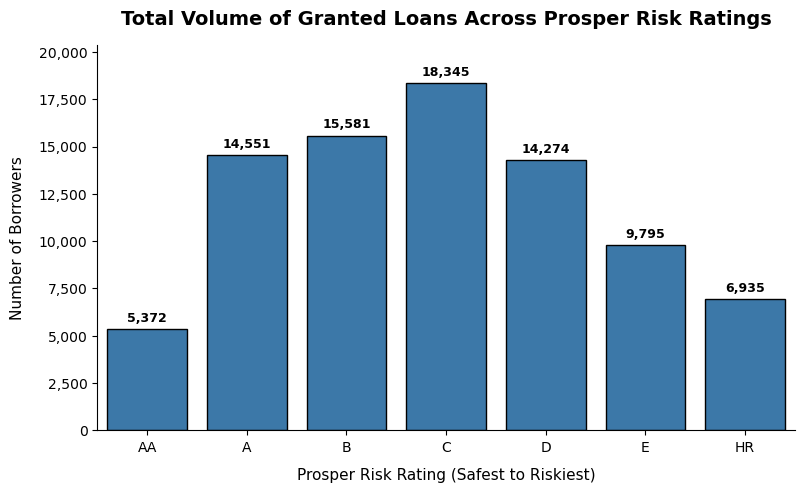

In [28]:
plt.figure(figsize=[9, 5])

# Define a stable, dark blue color for the baseline univariate count plot
base_color = sns.color_palette("Blues_r")[1]

# Plot the distribution of alpha risk scores
sns.countplot(data=df, x='ProsperRating (Alpha)', color=base_color, edgecolor='black')

apply_plot_styles('Total Volume of Granted Loans Across Prosper Risk Ratings', 
                  'Prosper Risk Rating (Safest to Riskiest)', 
                  'Number of Borrowers',
                  add_commas=True)


# Add exact frequency counts above each bar (with commas, no decimals)
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height):,}',
                           (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='center', 
                           xytext=(0, 8), 
                           textcoords='offset points',
                           fontsize=9, weight='bold')

plt.ylim(0, df['ProsperRating (Alpha)'].value_counts().max() + 2000)
plt.show()

### Summary of Findings:
* **The High Volume Middle Tiers:** The marketplace relies heavily on moderate-risk borrowers. Tiers `B`, `C`, and `D` hold the largest share of applications on the platform, with tier `C` representing the single highest operational volume.
* **Conservative Extremes:** Prosper maintains a highly selective framework at the extreme edges. Both the absolute safest premium tier (`AA`) and the highest risk tier (`HR`) show much lower transaction volumes, protecting the platform from structural imbalance.

## Credit Performance: Measuring Real-World Default Risk

#### Question:
How accurately do Prosper's internal risk ratings map against actual, historical loan completion and default rates?

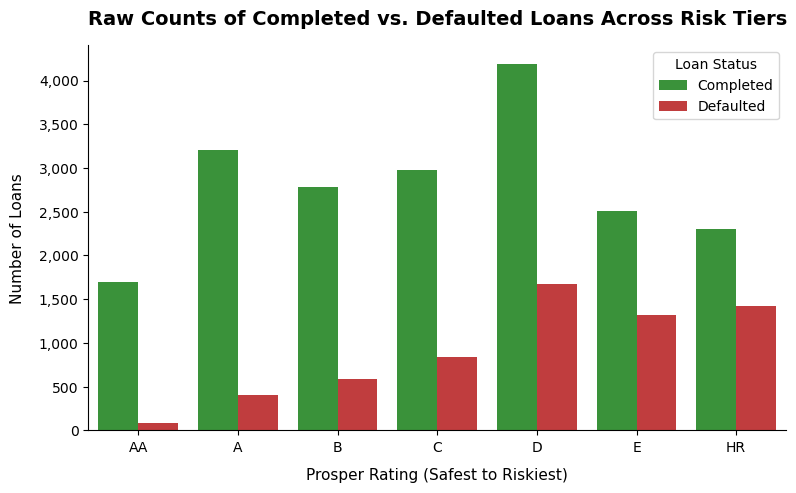

In [29]:
# Plot 7: Clustered Count Plot
plt.figure(figsize=[9, 5])

# FIX: Added hue_order to guarantee green matches Completed and red matches Defaulted
sns.countplot(data=df_closed, 
              x='ProsperRating (Alpha)', 
              hue='LoanStatusClean', 
              palette=['#2ca02c', '#d62728'],
              hue_order=['Completed', 'Defaulted'])

# Call custom function with add_commas=True to format raw numbers automatically
apply_plot_styles('Raw Counts of Completed vs. Defaulted Loans Across Risk Tiers', 
                  'Prosper Rating (Safest to Riskiest)', 
                  'Number of Loans', 
                  add_commas=True)
plt.legend(title='Loan Status')

plt.show()

### Summary of Findings:
* **The Rating Matrix works accurately:** As the risk rating drops from `AA` down toward `HR`, the proportion of defaulted loans (red bars) expands visually relative to completed loans (green bars). This proves that the internal risk model tracks real borrower performance cleanly.
* **Volume Anchors:** These charts highlight that while the proportion of defaults climbs aggressively in high-risk categories like `E` and `HR`, the absolute highest volume of successful repayments resides directly in the moderate-risk middle tiers (`B` and `C`).

## Credit Score Domination: Driving Loan Sizes and Interest Rates

#### Question:
How do Loan Original Amount and Borrower APR interact across different borrower credit score profiles?

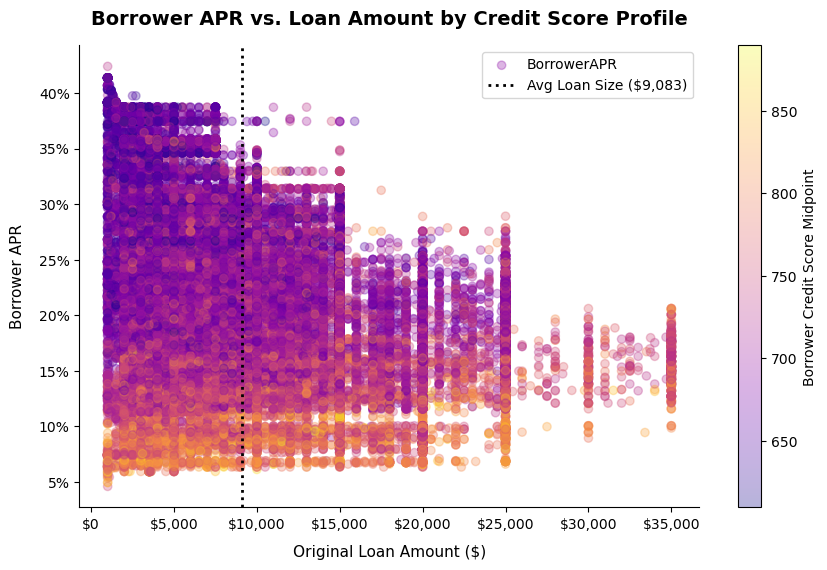

In [30]:
# Plot 11: Scatterplot with multiple encodings (Color mapped to credit score)
plt.figure(figsize=[10, 6])

# FIX: Changed 'viridis_r' to 'viridis' to make low credit scores pop out in bright colors
scatter = plt.scatter(data=df, x='LoanOriginalAmount', y='BorrowerAPR', 
                      c='CreditScore', cmap='plasma', alpha=0.3)

# Add an annotation line showing the overall average loan size across the entire platform
avg_loan_amt = df['LoanOriginalAmount'].mean()
plt.axvline(avg_loan_amt, color='black', linestyle=':', linewidth=2, label=f'Avg Loan Size (${avg_loan_amt:,.0f})')

# Format axes using our helper function
apply_plot_styles('Borrower APR vs. Loan Amount by Credit Score Profile', 
                  'Original Loan Amount ($)', 'Borrower APR', 
                  is_percent=True, percent_axis='y')

# Format X-axis with clean currency/comma labels
plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(lambda x, p: f"${format(int(x), ',')}"))

# Create color bar label
cbar = plt.colorbar(scatter)
cbar.set_label('Borrower Credit Score Midpoint')

plt.legend()
plt.show()

### Summary of Findings:
* **High Credit Scores (Bright Yellow/Orange):** Borrowers with excellent credit scores heavily dominate the lower-right side of the chart. They easily secure the largest loans (extending past the vertical average dotted line) while paying the lowest overall interest rates.
* **Low Credit Scores (Dark Purple/Blue):** Borrowers with lower credit scores are entirely confined to the upper-left quadrant. The platform limits them to small loan amounts and charges them the highest interest rates on the platform to mitigate risk.

## Risk Ratings vs. Income Level: Protecting Capital over Earnings

#### Question:
How does the average loan amount granted vary across combinations of Prosper Risk Tiers and Income Ranges?

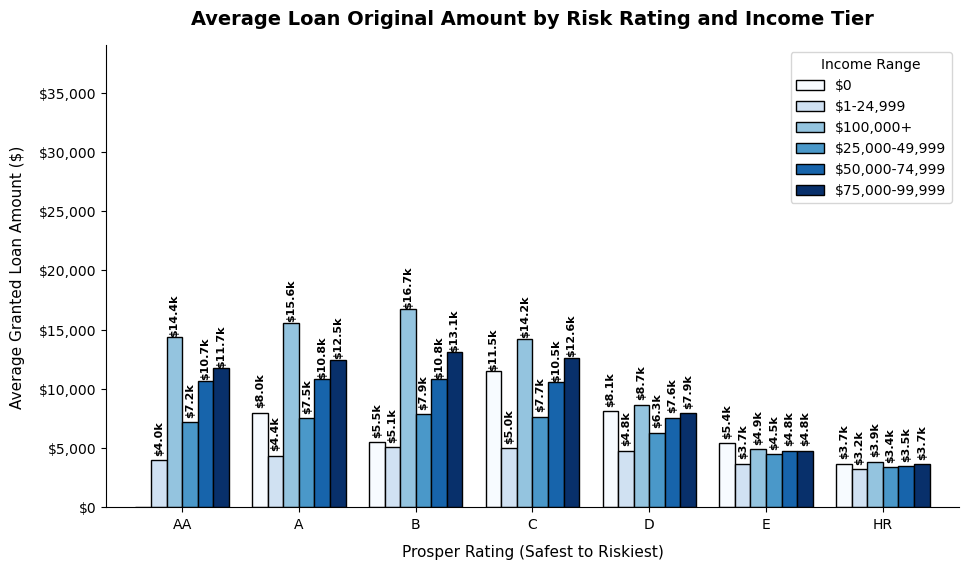

In [31]:
# Plot 12: Clustered Bar Chart with numbers clearly floating above the bars
plt.figure(figsize=[11, 6])

# Filter out 'Not displayed' income to make the narrative much cleaner
df_filtered = df[df['IncomeRange'] != 'Not displayed']

# Calculate means using observed=False to avoid future pandas warnings
pivot_df = df_filtered.pivot_table(index='ProsperRating (Alpha)', 
                                   columns='IncomeRange', 
                                   values='LoanOriginalAmount', 
                                   aggfunc='mean',
                                   observed=False)

# Plot grouped clusters
pivot_df.plot(kind='bar', figsize=[11, 6], cmap='Blues', edgecolor='black', width=0.8, ax=plt.gca())

# Add numeric text annotations directly ABOVE the columns of the chart
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:  # Only annotate bars that actually contain data
        plt.gca().annotate(f"${height/1000:.1f}k", 
                           (p.get_x() + p.get_width() / 2., height), 
                           ha='center', va='center', 
                           xytext=(0, 16),             # FIX 1: Increased from 8 to 12 to push text higher up
                           textcoords='offset points', 
                           fontsize=8,                 # FIX 2: Slightly larger font size
                           weight='bold',              # FIX 3: Bold text so it stands out sharply
                           rotation=90)

apply_plot_styles('Average Loan Original Amount by Risk Rating and Income Tier', 
                  'Prosper Rating (Safest to Riskiest)', 
                  'Average Granted Loan Amount ($)')

# Clean up layout styling and expand the Y-axis limit slightly so top text has room
plt.gca().yaxis.set_major_formatter(tkr.FuncFormatter(lambda x, p: f"${format(int(x), ',')}"))
plt.legend(title='Income Range', loc='upper right')
plt.xticks(rotation=0)

# FIX 4: Add extra padding to the top of the graph (+4000) so the highest labels don't get cut off
plt.ylim(0, df['LoanOriginalAmount'].max() + 4000)

plt.show()

### Summary of Findings:
* **Risk Controls Income:** Within every risk tier, higher earners (\$100,000+) get larger average loans. However, for the riskiest tier (`HR`), the platform tightly caps loan sizes for everyone, completely overriding high income to protect investor capital.
* **The $0 Income Explained:** Borrowers reporting `$0` income still receive substantial average loans (especially in safe tiers like `AA`). This occurs because the chart tracks **loan money approved**, not earnings. These borrowers are usually high-quality applicants backed by strong household income, cash assets, or co-signers (like students or stay-at-home spouses).

# Thank You!